In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARIMA

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [46]:
df = pd.read_csv('EUR_GBP_estimates_v2.csv')

In [47]:
df.columns

Index(['Unnamed: 0', 'CURRENCY', 'CURRENCY_DENOM', 'TIME_PERIOD', 'OBS_VALUE',
       'hourly_rate_45_pounds', 'hourly_rate_40_pounds',
       'hourly_rate_50_pounds', 'hourly_rate_55_pounds',
       'hourly_rate_60_pounds', 'hourly_rate_65_pounds',
       'hourly_rate_70_pounds', 'YEAR', 'MONTH', 'WEEK'],
      dtype='str')

In [48]:
df = df[['TIME_PERIOD','YEAR', 'MONTH', 'WEEK', 'OBS_VALUE']]

In [49]:
df

,TIME_PERIOD,YEAR,MONTH,WEEK,OBS_VALUE
0,2002-01-01,2002,1,1,NaN
1,2002-01-02,2002,1,1,0.62620
2,2002-01-03,2002,1,1,0.62540
3,2002-01-04,2002,1,1,0.62170
4,2002-01-07,2002,1,2,0.61940
...,...,...,...,...,...
6171,2026-03-04,2026,3,10,0.87050
6172,2026-03-05,2026,3,10,0.86950
6173,2026-03-06,2026,3,10,0.86693
6174,2026-03-09,2026,3,11,0.86530


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6176 entries, 0 to 6175
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TIME_PERIOD  6176 non-null   str    
 1   YEAR         6176 non-null   int64  
 2   MONTH        6176 non-null   int64  
 3   WEEK         6176 non-null   int64  
 4   OBS_VALUE    6127 non-null   float64
dtypes: float64(1), int64(3), str(1)
memory usage: 241.4 KB


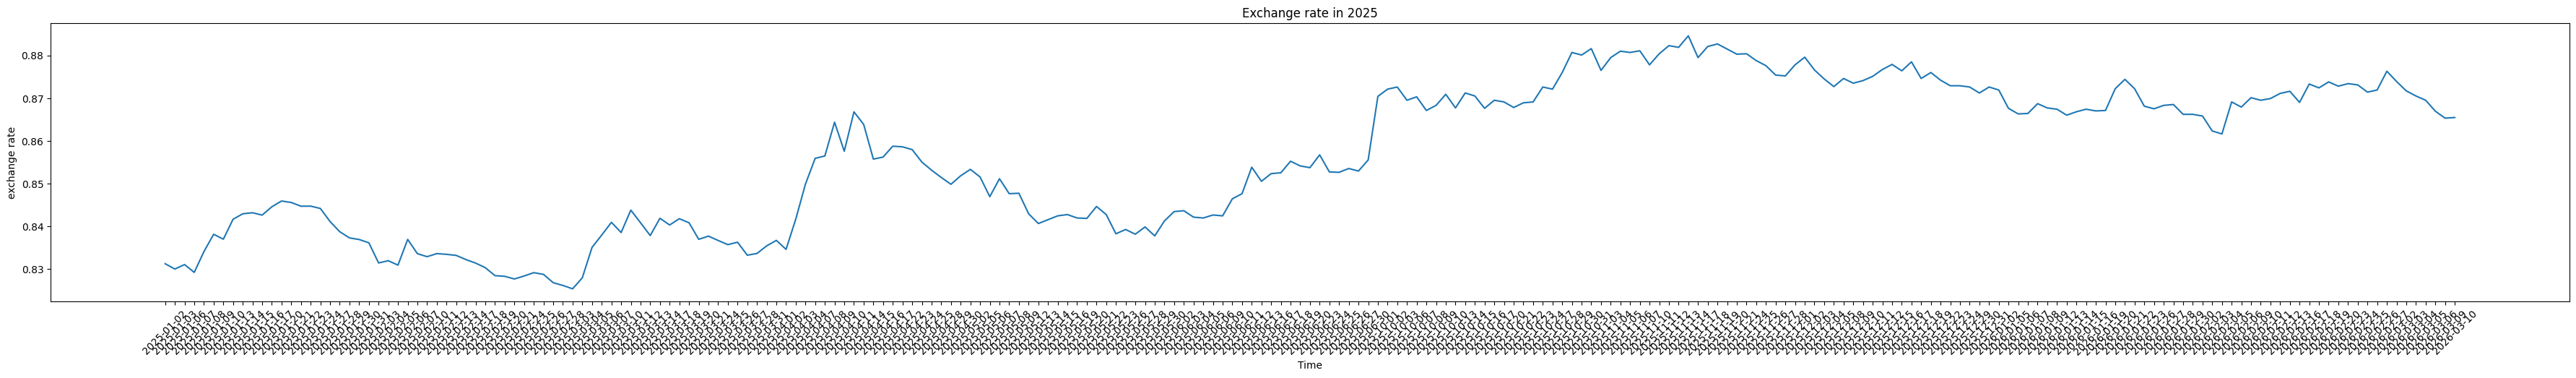

In [51]:
plt.figure(figsize=(45,5))
plt.title('Exchange rate in 2025')
plt.ylabel('exchange rate')
plt.xlabel('Time')

x = df[df['YEAR']>=2025]['TIME_PERIOD'] 
y = df[df['YEAR']>=2025]['OBS_VALUE']

plt.plot( x, y)
plt.xticks(rotation = 45);

In [52]:
df['lag_1d'] = df['OBS_VALUE'].shift(1)
df['lag_2d'] = df['OBS_VALUE'].shift(2)

df['OBS_VALUE'] = df['OBS_VALUE'].fillna(df['lag_1d'])
df['OBS_VALUE'] = df['OBS_VALUE'].fillna(df['lag_2d'])
df = df[df['TIME_PERIOD']> '2002-01-01']

In [53]:
col = 'OBS_VALUE'

test_staticist = adfuller(df[col])[0]
adf_criticatical_value_5perc = adfuller(df[col])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{col}_diff'] = df[col] - df[col].shift( 1) # qui facciamo subito la differnziazione

else:
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')

-2.35 > -2.86 ==> The time series is NON stationary


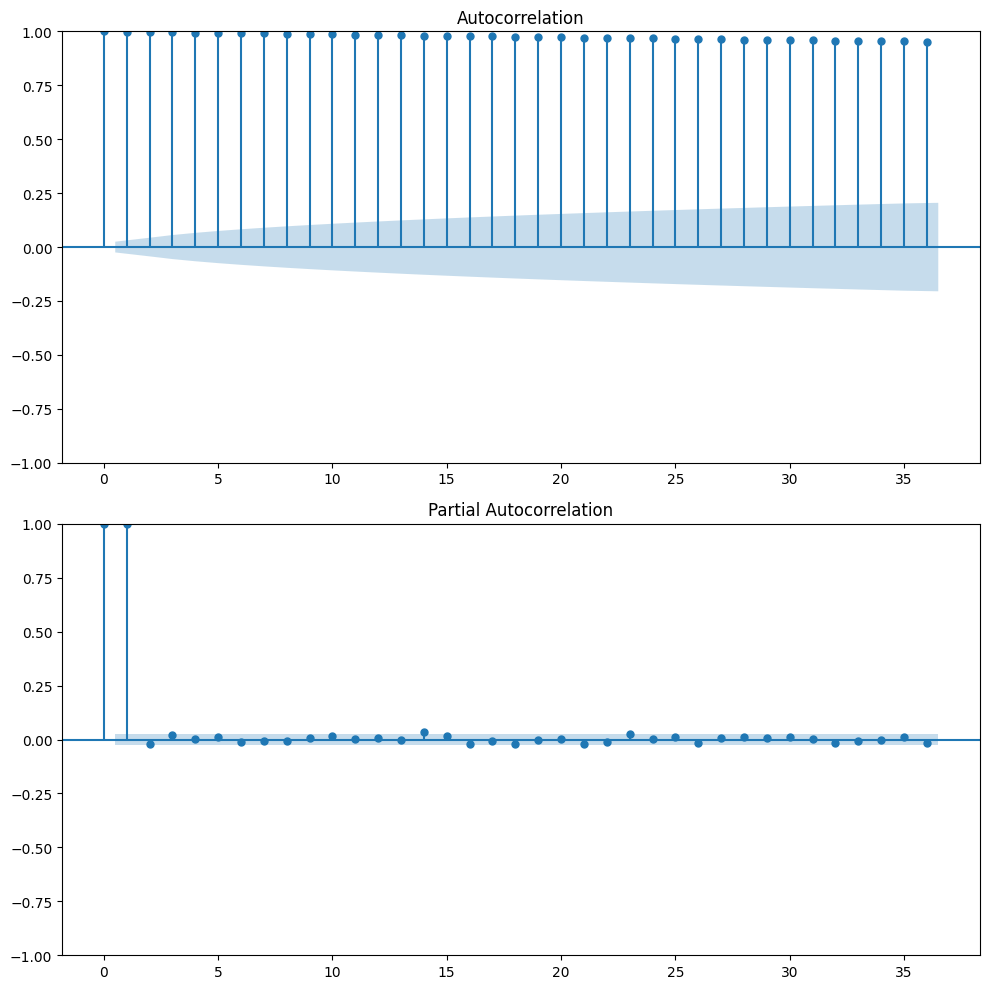

In [54]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df[col],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df[col],lags=36, ax=ax[1], alpha=0.05, method="ywm")

# ax[1].annotate('Strong correlation at lag = 1', xy=(1, 0.6),  xycoords='data',
#             xytext=(0.17, 0.75), textcoords='axes fraction',
#             arrowprops=dict(color='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

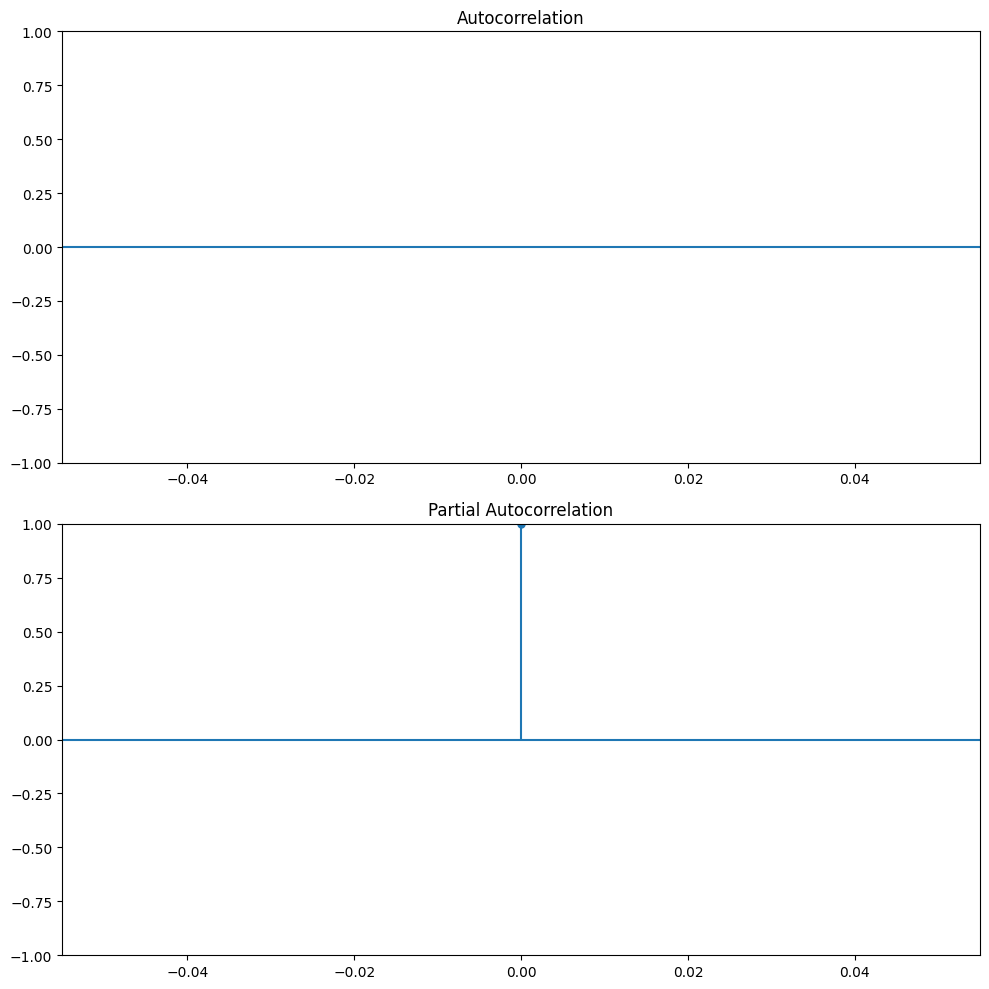

In [55]:
col2 = 'OBS_VALUE_diff'

width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df[col2],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df[col2],lags=36, ax=ax[1], alpha=0.05, method="ywm")

# ax[1].annotate('Strong correlation at lag = 1', xy=(1, 0.6),  xycoords='data',
#             xytext=(0.17, 0.75), textcoords='axes fraction',
#             arrowprops=dict(color='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

In [56]:
df['rolling_mean_1d'] = df[col].rolling(window=1).mean()
df['rolling_mean_2d'] = df[col].rolling(window=2).mean()
df['rolling_mean_3d'] = df[col].rolling(window=3).mean()
df['rolling_mean_9d'] = df[col].rolling(window=9).mean()
df['rolling_mean_20d'] = df[col].rolling(window=20).mean()
df['rolling_mean_60d'] = df[col].rolling(window=60).mean()

df['rolling_std_1d'] = df[col].rolling(window=1).std()
df['rolling_std_2d'] = df[col].rolling(window=2).std()
df['rolling_std_3d'] = df[col].rolling(window=3).std()
df['rolling_std_9d'] = df[col].rolling(window=9).std()
df['rolling_std_20d'] = df[col].rolling(window=20).std()
df['rolling_std_60d'] = df[col].rolling(window=60).std()

df['lag_1d'] = df[col].shift(1)
df['lag_2d'] = df[col].shift(2)
df['lag_3d'] = df[col].shift(3)
df['lag_12d'] = df[col].shift(12)


In [63]:
df  = df[df['rolling_std_60d'].isnull()==False]

In [67]:
df.drop('rolling_std_1d', inplace = True , axis = 1 )

In [69]:
df.isnull().sum()

TIME_PERIOD         0
YEAR                0
MONTH               0
WEEK                0
OBS_VALUE           0
lag_1d              0
lag_2d              0
OBS_VALUE_diff      0
rolling_mean_1d     0
rolling_mean_2d     0
rolling_mean_3d     0
rolling_mean_9d     0
rolling_mean_20d    0
rolling_mean_60d    0
rolling_std_2d      0
rolling_std_3d      0
rolling_std_9d      0
rolling_std_20d     0
rolling_std_60d     0
lag_3d              0
lag_12d             0
dtype: int64

In [68]:
df.shape

(6116, 21)

In [70]:
df.to_csv('EUR_GBP_dataset.csv', index = False)